# BioJEPA v0.7 Training Pipeline

In [2]:
import torch
import random
import gc
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import numpy as np

from biojepa_v0_7 import BioJepa, BioJepaConfig
from dataloader_v0_7 import EncoderLoader, ComposerLoader, TrainingLoader
from training_v0_7 import create_model, load_feature_banks, run_encoder_training, run_composer_training, run_ac_training, train_linear_decoder, maybe_compile
from config_v0_7 import EncoderTrainingConfig, ComposerTrainingConfig, ACTrainingConfig, DecoderConfig, DataConfig
from evals.evals import EvalContext, run_encoder_evals, run_composer_evals, run_ac_evals, save_report

## Device & Paths

In [3]:
SEED = 1337

def get_device():
    device = 'cpu'
    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)
        device = 'cuda'
    print(f'using {device}')
    return torch.device(device)

torch.manual_seed(SEED)
random.seed(SEED)
torch.set_float32_matmul_precision('high')

device = get_device()

USE_AMP = torch.cuda.is_available()
USE_COMPILE = torch.cuda.is_available()
USE_FUSED = torch.cuda.is_available()

data_root = Path('~/data/v0_7').expanduser()
ref_root = Path('~/data/reference_data').expanduser()

data_cfg = DataConfig(
    data_root=data_root,
    checkpoint_dir=data_root / 'checkpoint',
    ref_dir = ref_root,
    eval_results_dir=data_root / 'eval_results'
)

using cuda


## Hyperparameters

In [4]:
# Model architecture -- Trial 39 winning recipe (75/25 T22/T23 interpolation), composite 0.8853 at ep4
# Predictor dims decoupled from encoder: predictor HPO v1 winner (128/4/4, ~32.6% of encoder).
model_cfg = BioJepaConfig(
    num_genes=10000,
    n_layer=6,
    heads=4,
    embed_dim=256,
    mlp_ratio=4.0,
    n_pre_layer=2,
    mask_ratio=0.766,
    gaussian_scale=5.699,
    film_linear_multiple=0.6769,
    sim_coeff=50.18,
    std_coeff=25.44,            # sim_coeff * std_to_sim_ratio (0.5069)
    cov_coeff=0.5158,           # sim_coeff * cov_to_sim_ratio (0.01028)
    pert_latent_dim=128,
    pert_mode_dim=64,
    predictor_embed_dim=128,
    predictor_n_layer=4,
    predictor_heads=4,
)

# Encoder short: 10 epochs. Rampup matches HPO absolute timing (HPO used 50-ep schedule with
# warmup_pct=0.05 -> 2.5 ep absolute warmup). Setting warmup_pct=0.25 here reproduces the same
# 2.5 ep absolute warmup over the 10-ep horizon. context_coeff=0.0 matches HPO (ramp never fired
# in 4-ep trials). phase2_start_pct=0.8 adds production-style decay over the last 2 epochs.
encoder_cfg = EncoderTrainingConfig(
    epochs=10, lr=6.126e-5, batch_size=64,
    warmup_pct=0.25, weight_decay=0.05, phase2_start_pct=0.8,
    context_coeff=0.0, ema_final_momentum=None,
)

# Composer: v11 alignment HPO winner (trial #42, composite 0.6949 at 10k-epoch horizon)
composer_cfg = ComposerTrainingConfig(
    epochs=10000, lr=2.147e-4, batch_size=64, weight_decay=2.512e-3, temperature=7.559e-4, chemical_fraction=0.1,
)

# AC short: 5 epochs. Predictor HPO v1 winner (128/4/4, middle-of-plateau).
# lr 4e-3 tuned at batch 64; beta_nll_target 0.95 (plateau 0.9-1.0); mask anneal over last 2 ep.
ac_cfg = ACTrainingConfig(
    epochs=5, predictor_lr=4e-3, batch_size=64, beta_nll_target=0.95,
    mask_anneal_pct=0.4, mask_anneal_floor=0.0, composer_lr_mult=0.01,
)

# Decoder short: 5 epochs. Linear head converges in 3-5 epochs.
decoder_cfg = DecoderConfig(epochs=5, lr=1e-3, batch_size=32)

## Initialize Model & Data

In [5]:
model = create_model(model_cfg, device)
model = maybe_compile(model, USE_COMPILE)
seq_banks, target_bank = load_feature_banks(data_cfg, device)

print(f'Student/Teacher: {sum(p.numel() for p in model.student.parameters() if p.requires_grad):,}')
print(f'ACpredictor: {sum(p.numel() for p in model.predictor.parameters() if p.requires_grad):,}')
print(f'PerturbationComposer: {sum(p.numel() for p in model.composer.parameters() if p.requires_grad):,}')

Loaded DNA embeddings: torch.Size([11643, 1536])
Loaded chemical embeddings: torch.Size([188, 1536])
Loaded target embeddings: torch.Size([9975, 320])
Student/Teacher: 7,979,522
ACpredictor: 2,565,760
PerturbationComposer: 444,224


### Load pretraining model from checkpoint (for resuming)

In [6]:
checkpoint_path = data_cfg.checkpoint_dir / 'biojepa_v0_7_encoder_epoch_3_final.pt'
checkpoint = torch.load(checkpoint_path, map_location=device)

# Predictor is trained fresh in the AC stage and its checkpoint shape (256/6) no longer matches the
# decoupled 128/4 predictor, so drop predictor.* before loading. strict=False tolerates the missing keys.
filtered = {k: v for k, v in checkpoint['model'].items() if not k.startswith('predictor.')}
keys = model.load_state_dict(filtered, strict=False)
assert all(k.startswith('predictor.') for k in keys.missing_keys) and not keys.unexpected_keys, keys
# model = maybe_compile(model, USE_COMPILE)
keys

_IncompatibleKeys(missing_keys=['predictor._orig_mod.in_proj.weight', 'predictor._orig_mod.in_proj.bias', 'predictor._orig_mod.adapter.0.weight', 'predictor._orig_mod.adapter.0.bias', 'predictor._orig_mod.adapter.1.weight', 'predictor._orig_mod.adapter.3.weight', 'predictor._orig_mod.adapter.3.bias', 'predictor._orig_mod.mask_queries.weight', 'predictor._orig_mod.blocks.0.ln_1.weight', 'predictor._orig_mod.blocks.0.action_attn.q_proj.weight', 'predictor._orig_mod.blocks.0.action_attn.q_proj.bias', 'predictor._orig_mod.blocks.0.action_attn.k_proj.weight', 'predictor._orig_mod.blocks.0.action_attn.k_proj.bias', 'predictor._orig_mod.blocks.0.action_attn.v_proj.weight', 'predictor._orig_mod.blocks.0.action_attn.v_proj.bias', 'predictor._orig_mod.blocks.0.action_attn.c_proj.weight', 'predictor._orig_mod.blocks.0.action_attn.c_proj.bias', 'predictor._orig_mod.blocks.0.action_attn.gate.weight', 'predictor._orig_mod.blocks.0.action_attn.gate.bias', 'predictor._orig_mod.blocks.0.ln_2.weight', '

## Function to decompress and recompress a directory

In [ ]:
def decompress_npz(root_dir):
    root_dir = Path(root_dir)
    for src_path in root_dir.rglob('*.npz'):
        print(f'decompress {src_path}')
        with np.load(src_path, allow_pickle=False) as data:
            arrays = {k: data[k] for k in data.files}
        tmp_path = src_path.with_suffix('.tmp.npz')
        np.savez(tmp_path, **arrays)
        tmp_path.replace(src_path)

def compress_npz(root_dir):
    root_dir = Path(root_dir)
    for src_path in root_dir.rglob('*.npz'):
        print(f'compress {src_path}')
        with np.load(src_path, allow_pickle=False) as data:
            arrays = {k: data[k] for k in data.files}
        tmp_path = src_path.with_suffix('.tmp.npz')
        np.savez_compressed(tmp_path, **arrays)
        tmp_path.replace(src_path)

In [ ]:
# decompress_npz(data_cfg.data_root / 'encoder_t')

In [ ]:
# compress_npz(data_cfg.data_root / 'encoder_t')

## Stage 0: Composer Training

In [ ]:
comp_train_loader = ComposerLoader(
    batch_size=composer_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'pert_embd', 
    device=device,
    seed=1337, chemical_fraction=composer_cfg.chemical_fraction)
comp_val_loader = ComposerLoader(
    batch_size=composer_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'pert_embd', 
    device=device)

In [ ]:
align_results = run_composer_training(model, comp_train_loader, comp_val_loader, seq_banks, 
                                      target_bank, composer_cfg, device, data_cfg.checkpoint_dir, 
                                      use_amp=USE_AMP, use_fused_optimizer=USE_FUSED)

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(align_results['loss_history'])
plt.yscale('log')
plt.title('Composer Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

### Composer Training Evals

In [ ]:
eval_config = {
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim,
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': composer_cfg.batch_size, 'seed': SEED
}
model.eval()
align_eval_ctx = EvalContext(config=eval_config, data_root=data_cfg.data_root, checkpoint_root=data_cfg.data_root, ref_dir=data_cfg.ref_dir)
align_eval_ctx._biojepa = model
align_eval_results = run_composer_evals(align_eval_ctx)
align_eval_ctx._biojepa = None

save_report(align_eval_results, data_cfg.eval_results_dir / 'composer_eval_report.json')
align_eval_results

In [ ]:
del comp_train_loader, comp_val_loader, align_eval_ctx
gc.collect()
torch.cuda.empty_cache()
model.train()

## Stage 1: Encoder Training

In [ ]:
enc_train_loader = EncoderLoader(
    batch_size=encoder_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'encoder_t', 
    device=device, seed=1337)
enc_val_loader = EncoderLoader(
    batch_size=encoder_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'encoder_t', 
    device=device, seed=1337)

In [ ]:
pt_results = run_encoder_training(model, enc_train_loader, enc_val_loader, encoder_cfg, device, data_cfg, model_cfg, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED, eval_every_n_epochs=1)

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(pt_results['loss_history'])
plt.yscale('log')
plt.title('Encoder Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

In [ ]:
if pt_results['epoch_evals']:
    evals_df = pd.DataFrame({e: d['metrics'] for e, d in pt_results['epoch_evals'].items()}).T
    evals_df.index = evals_df.index.astype(int)
    evals_df.index.name = 'epoch'
    evals_df.sort_index()

### Encoder Training Evals

In [ ]:
eval_config = {
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim,
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': encoder_cfg.batch_size, 'seed': SEED
}
model.eval()
eval_ctx = EvalContext(config=eval_config, data_root=data_cfg.data_root, checkpoint_root=data_cfg.data_root, ref_dir=data_cfg.ref_dir)
eval_ctx._biojepa = model
pt_eval_results = run_encoder_evals(eval_ctx)
eval_ctx._biojepa = None

save_report(pt_eval_results, data_cfg.eval_results_dir / 'encoder_eval_report.json')
pt_eval_results

In [ ]:
del enc_train_loader, enc_val_loader, eval_ctx
gc.collect()
torch.cuda.empty_cache()
model.train()

## Stage 2: AC Training

In [ ]:
train_loader = TrainingLoader(
    batch_size=ac_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'predictor_t', 
    device=device)
val_loader = TrainingLoader(
    batch_size=ac_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'predictor_t', 
    device=device)

full_results = run_ac_training(model, train_loader, val_loader, seq_banks, target_bank, ac_cfg, device, data_cfg.checkpoint_dir, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED)

found 1119 shards for split train
shard balancing (threshold=128, 20% of max=639):
  adamson: 22 -> 132 shards (x6)
  k562e_raw: 94 -> 188 shards (x2)
  k562gw: 639 shards
  norman: 35 -> 140 shards (x4)
  rep1e: 79 -> 158 shards (x2)
  sciplex: 250 shards
found 67 shards for split val
AC training: 3857920 samples, 60280 steps/epoch, 301400 total steps
Mask annealing: starts at step 180840 (0.766 -> 0.000)
Beta-NLL: target=0.95, anneal steps=120560
Step 0 | val loss: 112.0144
Step 0 | Loss: 111.10132 | LR: 1.60e-04 | Beta: 0.000
Step 1000 | Loss: 45.11836 | LR: 2.02e-04 | Beta: 0.008
Step 2000 | Loss: 46.64027 | LR: 3.25e-04 | Beta: 0.016
Step 3000 | Loss: 51.49052 | LR: 5.24e-04 | Beta: 0.024
Step 4000 | Loss: 38.62902 | LR: 7.90e-04 | Beta: 0.032
Step 6000 | Loss: 36.52921 | LR: 1.48e-03 | Beta: 0.047
Step 8000 | Loss: 35.68014 | LR: 2.27e-03 | Beta: 0.063
Step 9000 | Loss: 35.59922 | LR: 2.66e-03 | Beta: 0.071
Step 10000 | val loss: 42.0640
Step 10000 | Loss: 36.61293 | LR: 3.02e-03

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(full_results['loss_history'])
plt.title('AC Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

In [ ]:
del train_loader, val_loader
gc.collect()
torch.cuda.empty_cache()

## Linear Decoder Training

In [10]:
decoder_train_loader = TrainingLoader(
    batch_size=decoder_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'predictor_t', 
    device=device)
decoder_val_loader = TrainingLoader(
    batch_size=decoder_cfg.batch_size,
    split='val', data_dir=data_cfg.data_root / 'predictor_t',
    device=device)

decoder, decoder_results = train_linear_decoder(model, decoder_train_loader, decoder_val_loader, seq_banks, target_bank, model_cfg, device, data_cfg.checkpoint_dir, decoder_cfg, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED)

Decoder Step 297000 | Loss: 0.15328
Decoder Step 298000 | Loss: 0.16660
Decoder Step 299000 | Loss: 0.16585
Decoder Step 300000 | val loss: 0.3703
Decoder Step 300000 | Loss: 0.10822
Decoder Step 301000 | Loss: 0.11310
Decoder Step 302000 | Loss: 0.14886
Decoder Step 303000 | Loss: 0.33441
Decoder Step 304000 | Loss: 0.13395
Decoder Step 305000 | val loss: 0.1856
Decoder Step 305000 | Loss: 0.15221
Decoder Step 306000 | Loss: 0.17317
Decoder Step 307000 | Loss: 0.33354
Decoder Step 308000 | Loss: 0.16125
Decoder Step 309000 | Loss: 0.15518
Decoder Step 310000 | val loss: 0.1900
Decoder Step 310000 | Loss: 0.33581
Decoder Step 311000 | Loss: 0.10838
Decoder Step 312000 | Loss: 0.15612
Decoder Step 313000 | Loss: 0.17510
Decoder Step 314000 | Loss: 0.10431
Decoder Step 315000 | val loss: 0.1646
Decoder Step 315000 | Loss: 0.15425
Decoder Step 316000 | Loss: 0.15113
Decoder Step 317000 | Loss: 0.32411
Decoder Step 318000 | Loss: 0.18831
Decoder Step 319000 | Loss: 0.29223
Decoder Step 320

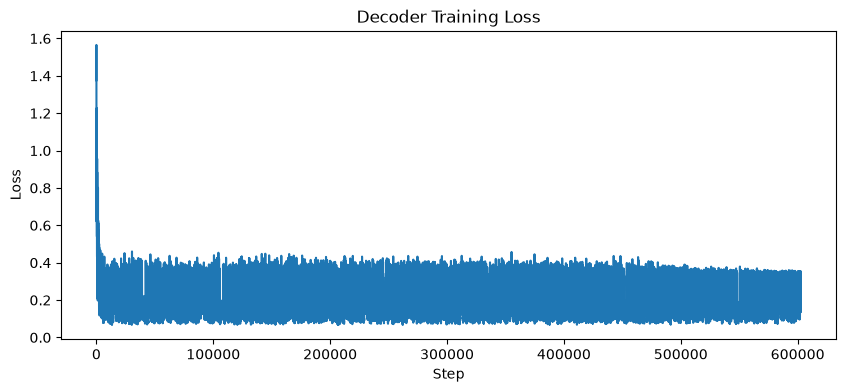

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(decoder_results['loss_history'])
plt.title('Decoder Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

## AC Evals

In [12]:
eval_config = {
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim,
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': ac_cfg.batch_size, 'seed': SEED
}
model.eval()
eval_ctx = EvalContext(config=eval_config, data_root=data_cfg.data_root, checkpoint_root=data_cfg.data_root, ref_dir=data_cfg.ref_dir)
eval_ctx._biojepa = model
eval_ctx._decoder = decoder
full_eval_results = run_ac_evals(eval_ctx)
eval_ctx._biojepa = None

save_report(full_eval_results, data_cfg.eval_results_dir / 'ac_eval_report.json')
full_eval_results

Using cuda
found 135 shards for split test


Running test inference:   0%|                                                              | 0/5400 [00:00<?, ?it/s]

Loaded DNA seq bank: torch.Size([11643, 1536])
Loaded chemical seq bank: torch.Size([188, 1536])
Loaded target bank: torch.Size([9975, 320])


Running test inference:   1%|▍                                                  | 40/5400 [00:20<4:14:02,  2.84s/it]/home/ubuntu/code/biojepa/evals/evals.py:643: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(p_top, t_top)
Running test inference: 100%|███████████████████████████████████████████████████| 5400/5400 [34:46<00:00,  2.59it/s]


Aggregated 1416 single-pert, 13 multi-pert perturbations, 345600 samples, 135 shards
  adamson: 11 perturbations, 4288 samples
  k562e_raw: 286 perturbations, 46506 samples
  k562gw: 1053 perturbations, 189095 samples
  norman: 10 perturbations, 9472 samples
  rep1e: 287 perturbations, 22838 samples
  sciplex: 54 perturbations, 73401 samples
Cached test inference to /home/ubuntu/data/v0_7/test_inference_cache (135 shards)
expression_prediction: Pearson=0.9873, R2=0.9679, Centroid_acc=0.1432
gene_level_analysis: Dir_acc=0.9820, Top50_acc=0.7191


perturbation_retrieval (dna): 100%|█████████████████████████████████████████████| 200/200 [1:13:59<00:00, 22.20s/it]


perturbation_retrieval (dna): MRR=0.0007


perturbation_retrieval (chemical): 100%|████████████████████████████████████████████| 54/54 [00:19<00:00,  2.81it/s]


perturbation_retrieval (chemical): MRR=0.0577
Loaded dataset gene masks: ['k562e_raw', 'rep1e', 'k562gw', 'adamson', 'norman', 'sciplex']
uncertainty_calibration: ECE=0.3258, Monotonicity=66.67%
Loading KEGG_2026...
  352 pathways loaded
Loading Reactome_Pathways_2024...
  2100 pathways loaded
moa_matching expression: Within=0.3245, Between=0.3088, Gap=0.0158, Ratio=1.0510x
moa_matching latent: Within=0.6986, Between=0.6934, Gap=0.0052, Ratio=1.0075x
Loaded Norman combo mapping: 132 combos
Loaded Norman single-gene deltas: 105 genes
Loaded Norman GI subtypes: 88 combos
Loaded dataset splits: ['k562e_raw', 'rep1e', 'k562gw', 'adamson', 'norman', 'sciplex']
combination_perturbation: 13 combo perts, 4283 samples, 13 additive baseline, 5 GI-labeled, 13 generalization-classified
dose_response: monotonicity=49.38%, real_mono=48.77%, spearman=-0.0208, curve_sim=0.524251186469342
Saved report to /home/ubuntu/data/v0_7/eval_results/ac_eval_report.json


{'expression_prediction': {'config': {'test_perturbations': 1416,
   'genes': 10000,
   'test_samples': 345600},
  'sample_level': {'mse': 0.19491597912909195,
   'pearson_r_top20': 0.8655672152070623},
  'perturbation_level': {'r2_all_genes': {'mean': 0.9679236104764507,
    'median': 0.9806753695011139},
   'r2_top50_degs': {'mean': 0.8075613574372174, 'median': 0.895409494638443},
   'mse': {'mean': 0.0072883302345871925, 'median': 0.004194831475615501},
   'pearson_all_genes': {'mean': 0.9873209024048121,
    'median': 0.9932067394256592},
   'pearson_delta_all_genes': {'mean': 0.33191792442763257,
    'median': 0.3323589414358139},
   'pearson_top50_degs': {'mean': 0.5986059478136821,
    'median': 0.6352928280830383}},
  'centroid_accuracy': {'accuracy': 0.14318010550113036, 'n_groups': 1327},
  'vs_baseline': {'beat_rate': 0.2846045197740113, 'n_evaluated': 1416},
  'severity': {'pearson_r': 0.7974509000778198,
   'spearman_r': 0.7798733489241534},
  'error_by_magnitude': {'0-0.

In [13]:
torch.save({
    'model': model.state_dict()
}, data_cfg.checkpoint_dir / f'biojepa_evaled_final.pt')

In [15]:
torch.save({
    'model': decoder.state_dict()
}, data_cfg.checkpoint_dir / f'biojepa_evaled_decoder_final.pt')

In [ ]:
del decoder_train_loader, decoder_val_loader, eval_ctx
gc.collect()
torch.cuda.empty_cache()

## Summary

In [ ]:
print('=== Training Complete ===')
print(f'Encoder training final loss: {pt_results["final_loss"]:.5f}')
print(f'Composer training final loss: {align_results["final_loss"]:.5f}')
print(f'AC training final loss: {full_results["final_loss"]:.5f}')
print(f'Decoder final loss: {decoder_results["final_loss"]:.5f}')
print(f'\nCheckpoints saved to: {data_cfg.checkpoint_dir}')
print(f'Eval reports saved to: {data_cfg.eval_results_dir}')